# Imports

In [16]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import sweetviz as sv

# Load Data

In [5]:
data = pd.read_csv('../data/Churn_Modelling.csv')

In [7]:
# Shape of data
data.shape

(10000, 14)

In [6]:
# Lets see how the data looks like
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Drop Unneccessary features

In [8]:
# Columns to drop
drop_cols = ['RowNumber', 'CustomerId', 'Surname']

# Drop cols
data = data.drop(drop_cols, axis=1)

# SweeetViz Report

In [18]:
# Run sweetviz report
report = sv.analyze(data, target_feat='Exited')

                                             |          | [  0%]   00:00 -> (? left)

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)



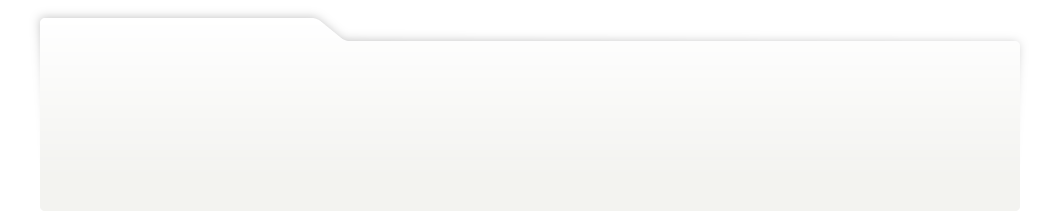
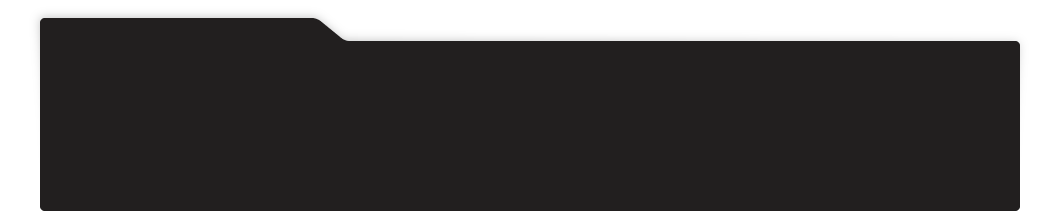
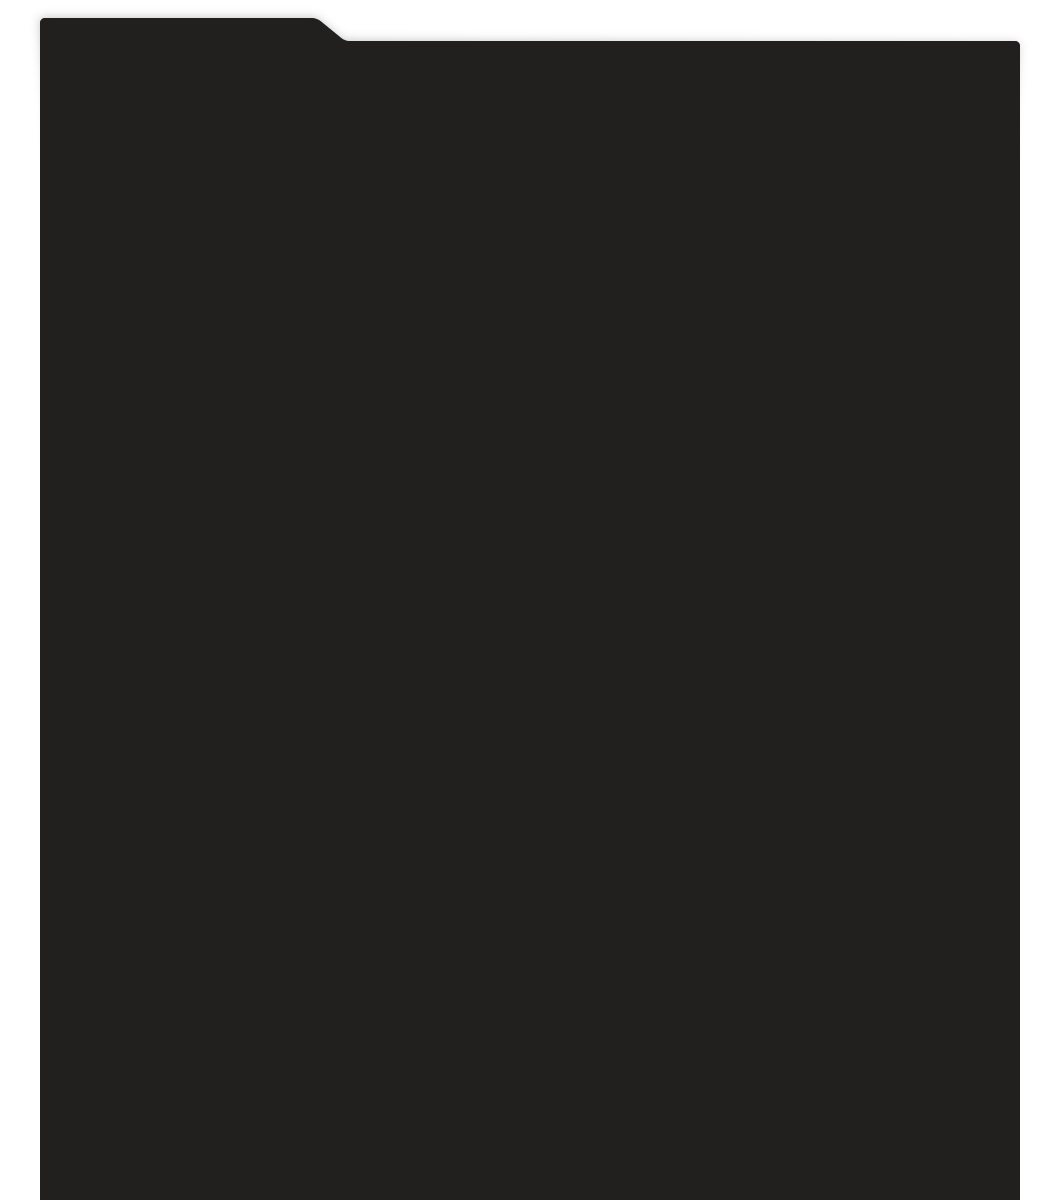
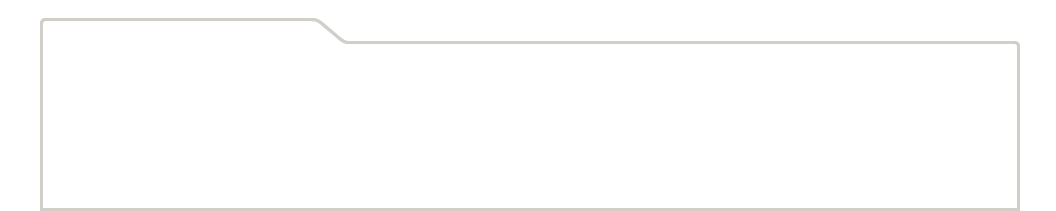
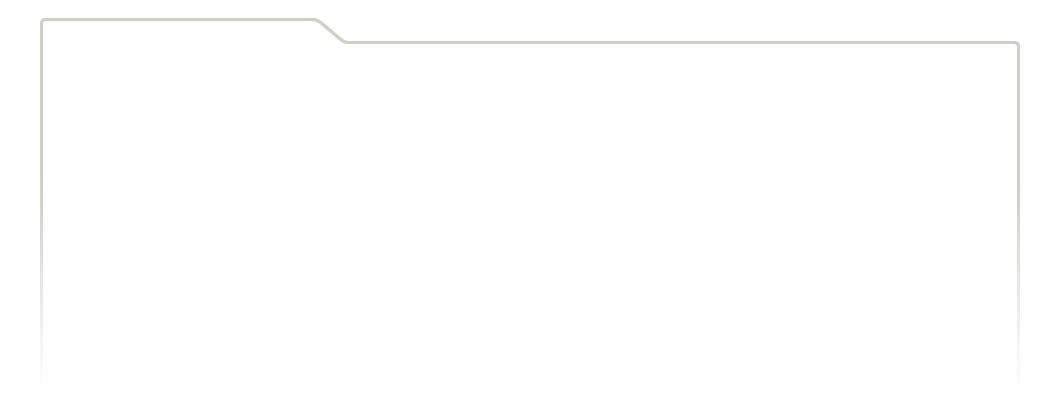
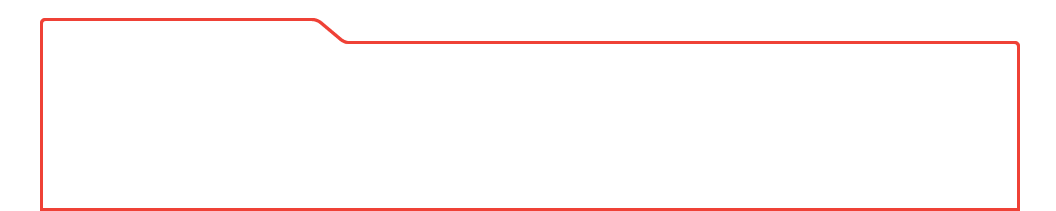
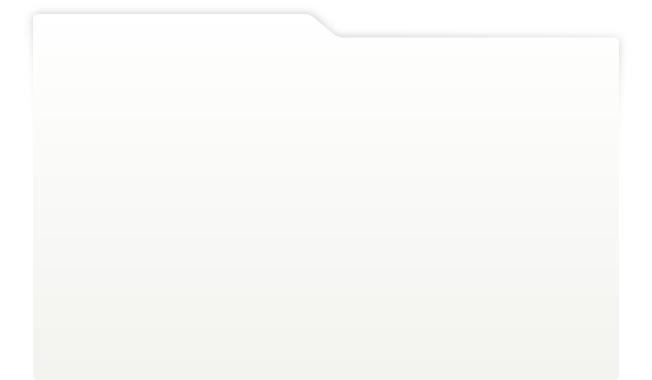
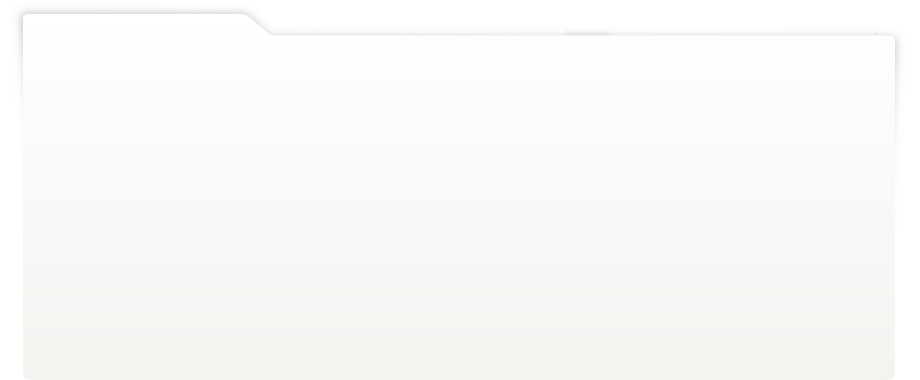
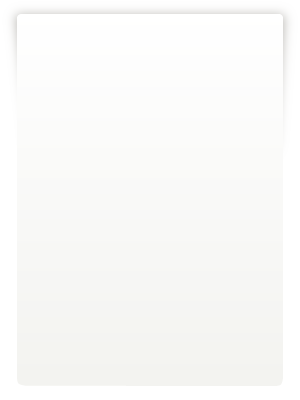
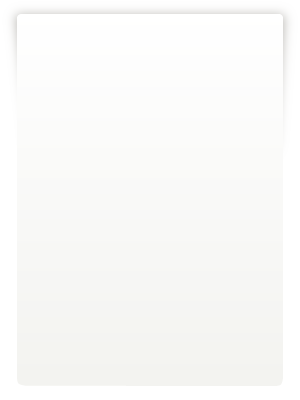
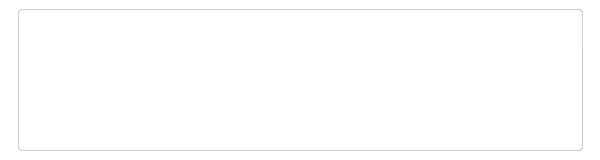
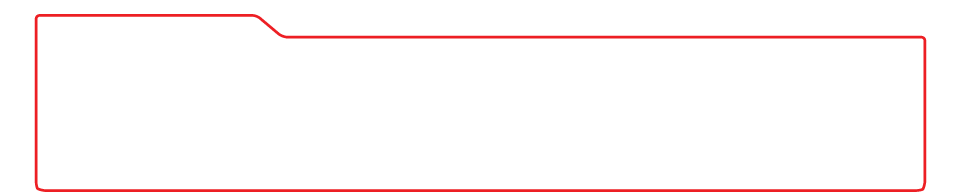
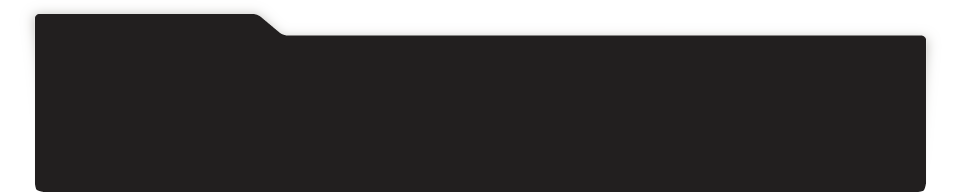
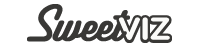
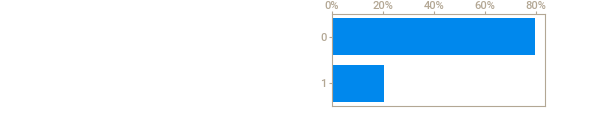
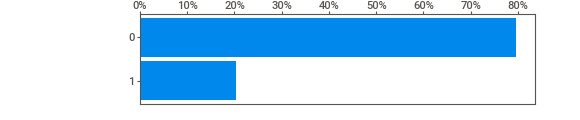
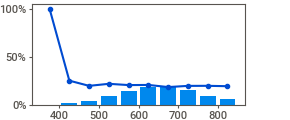
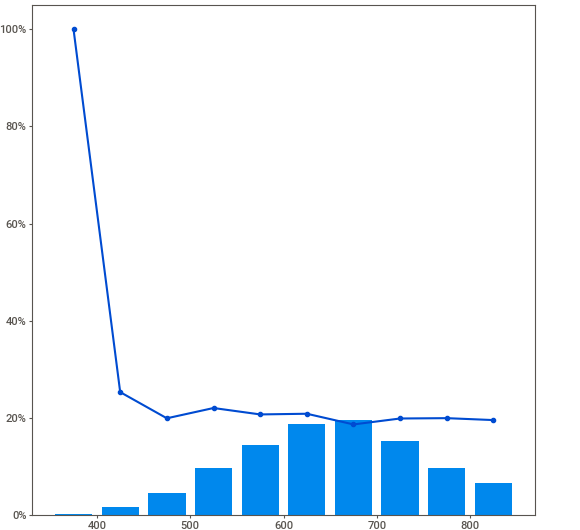
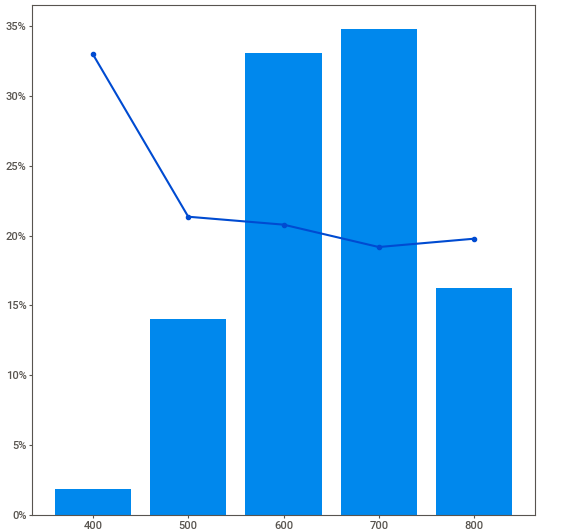
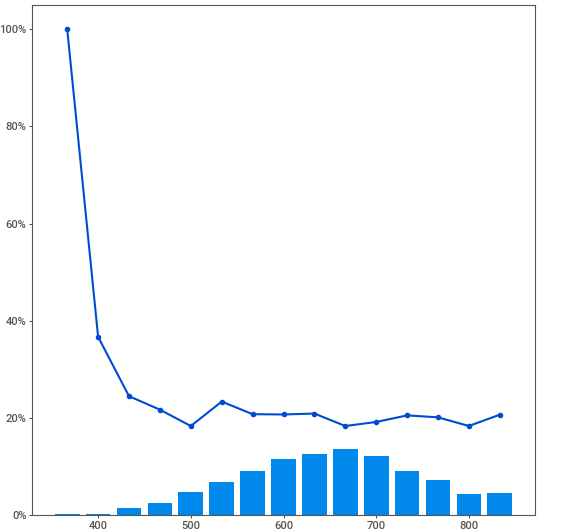
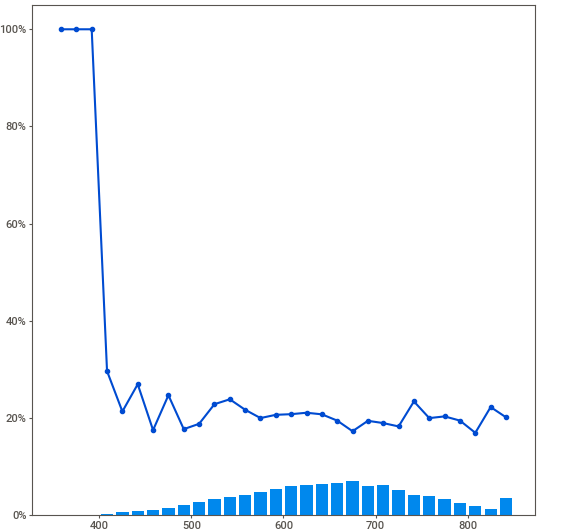
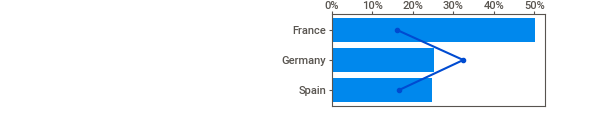
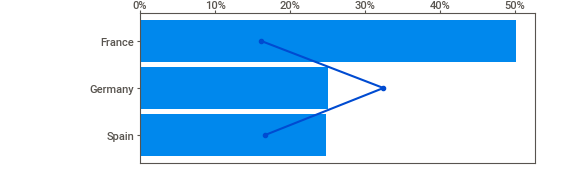
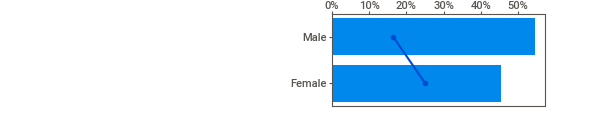
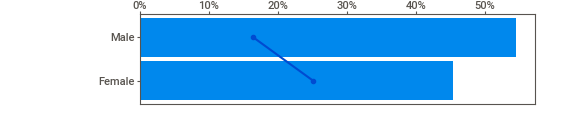
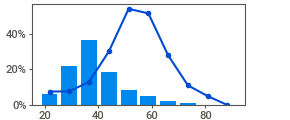
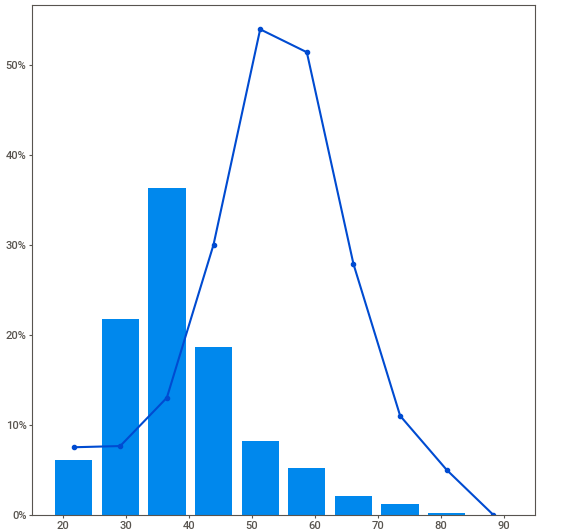
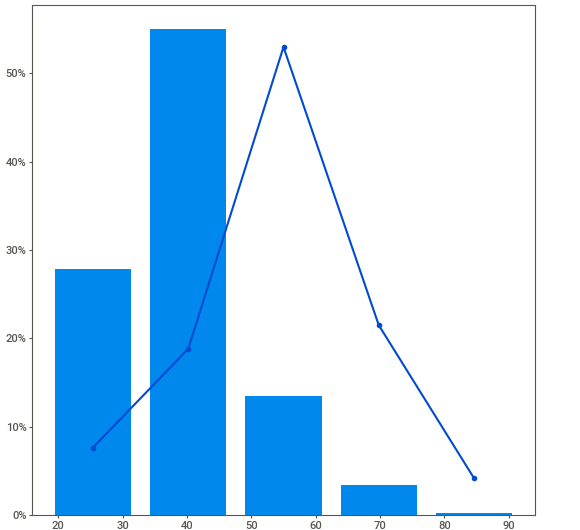
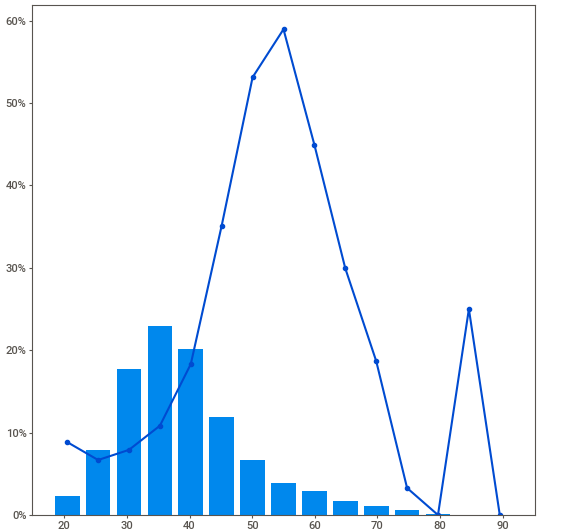
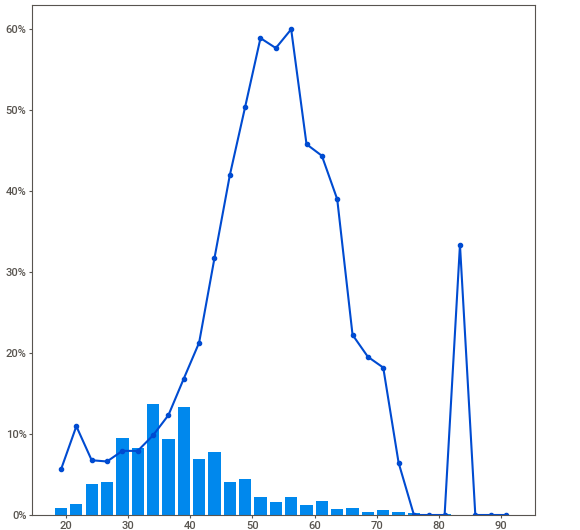
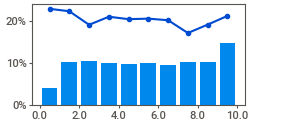
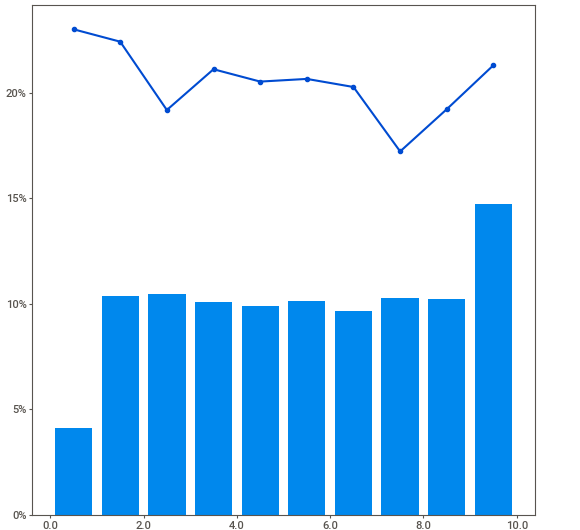
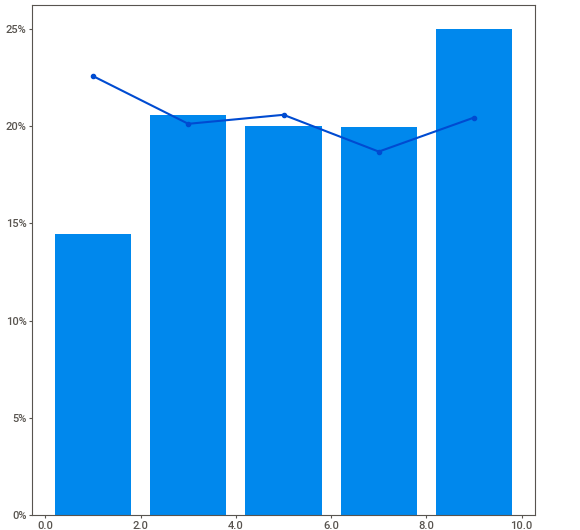
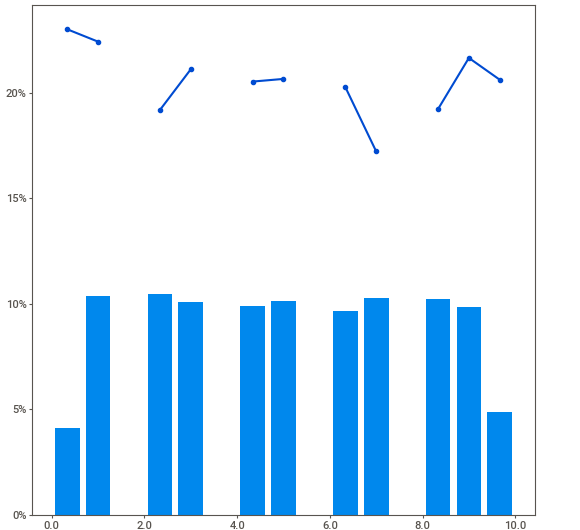
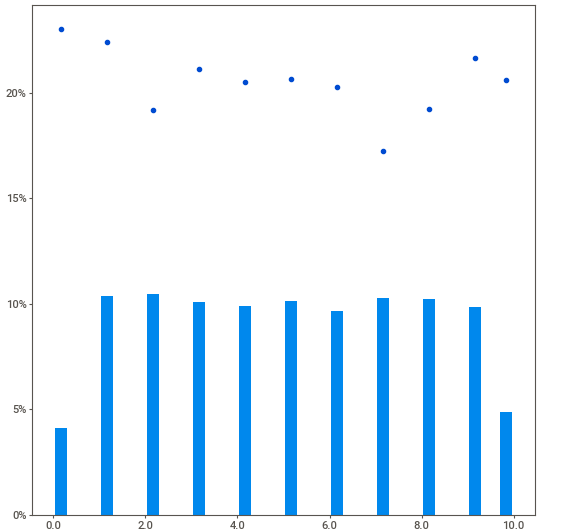
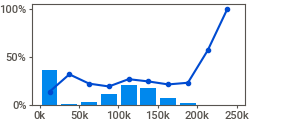
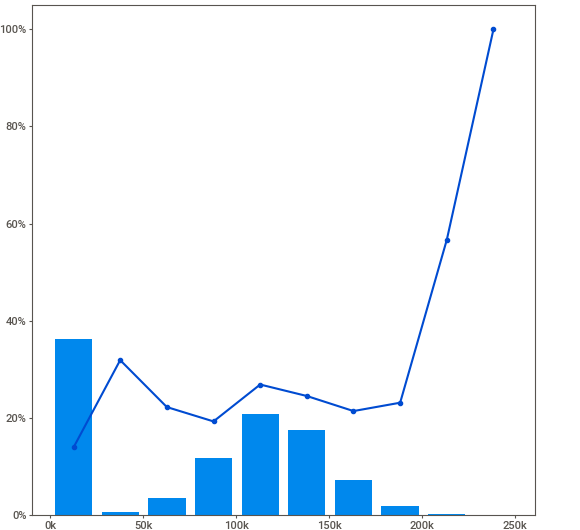
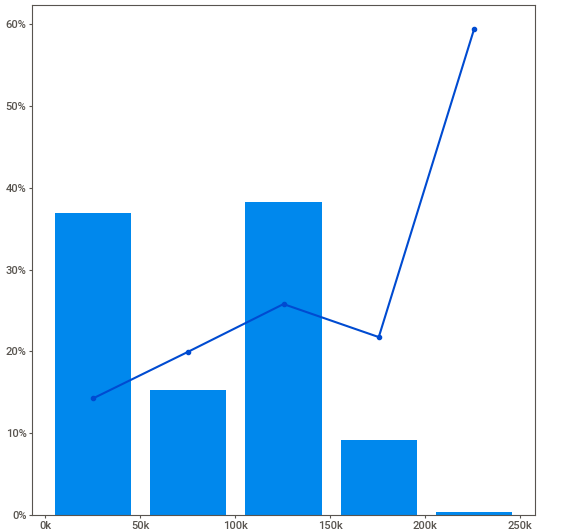
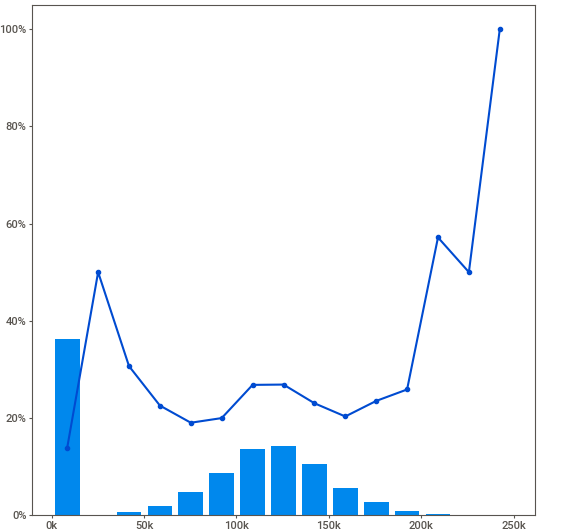
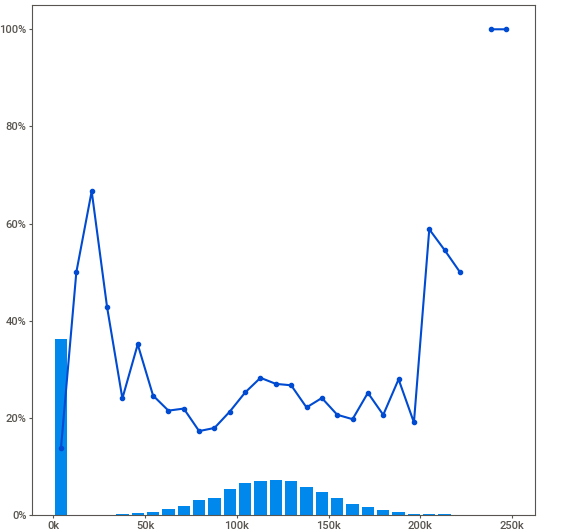
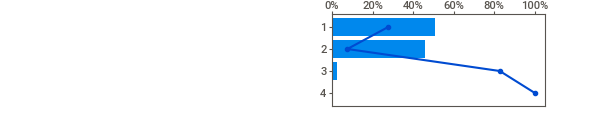
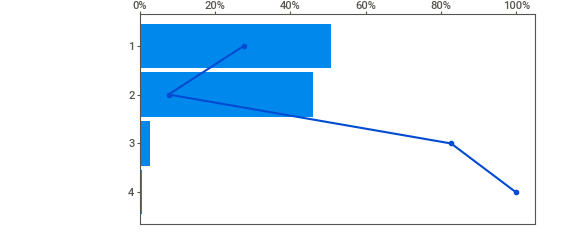
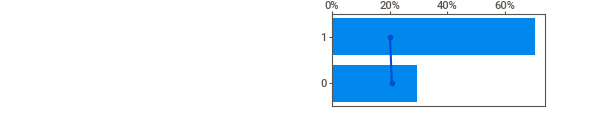
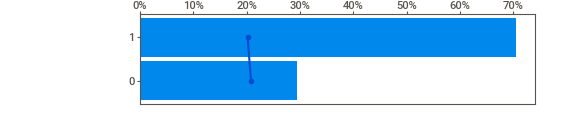
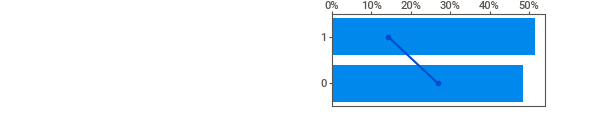
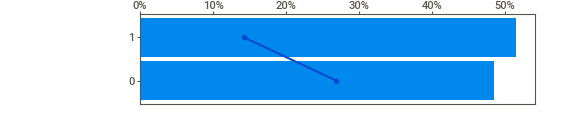
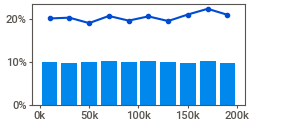
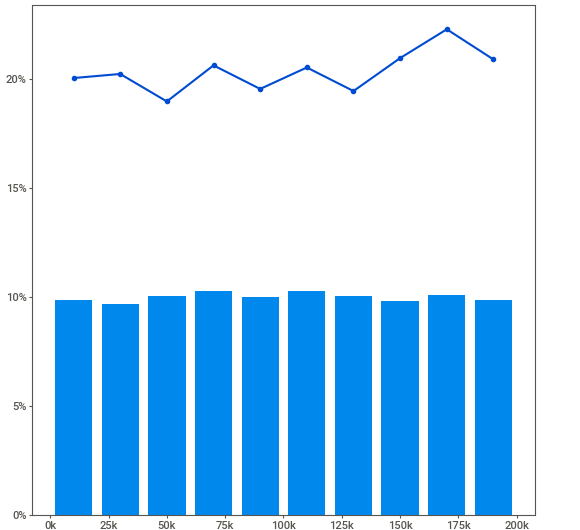
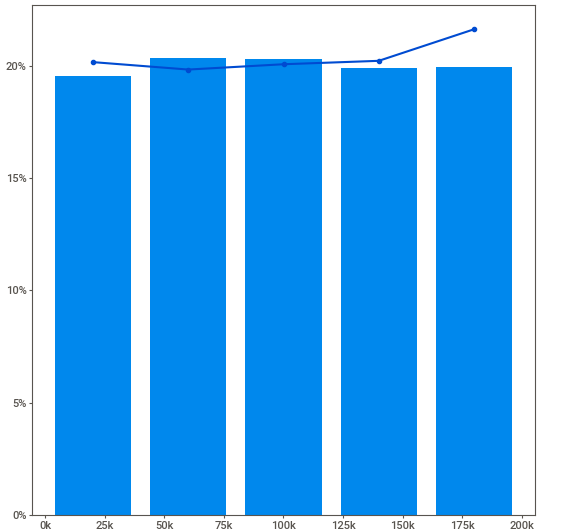
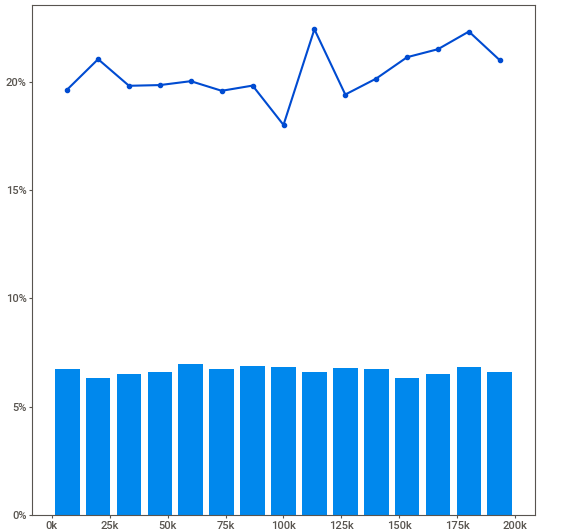
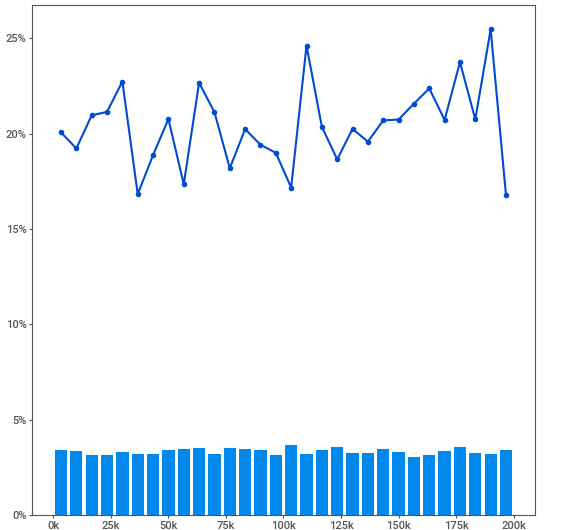
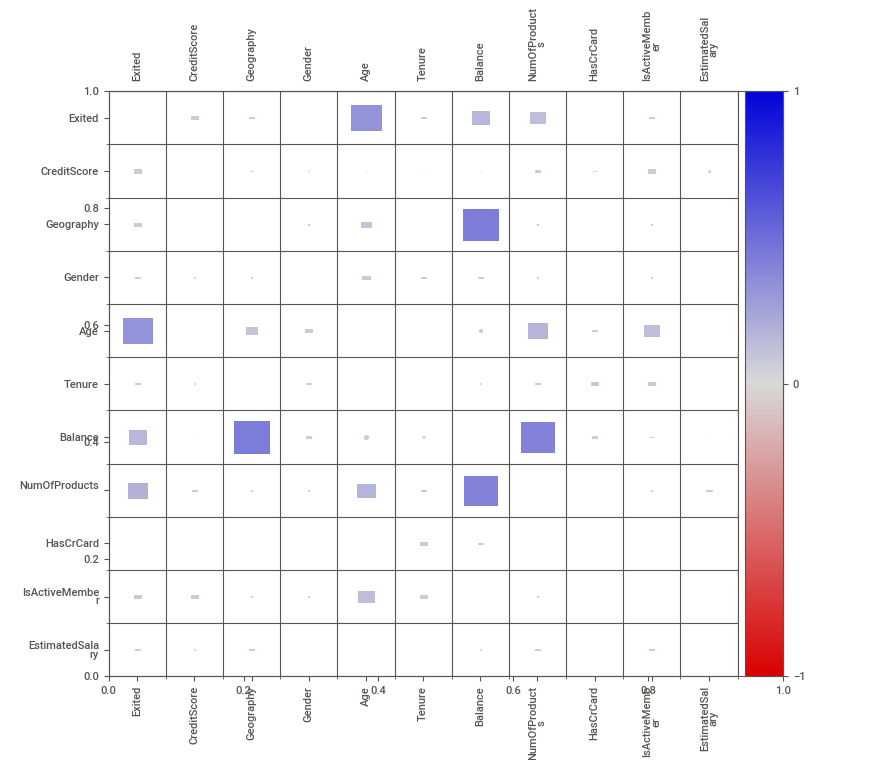
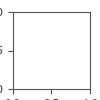

In [19]:
# Show report
report.show_notebook()

# Correlation Analysis

Text(0.5, 1.0, 'Correlation Analysis for Churn Features')

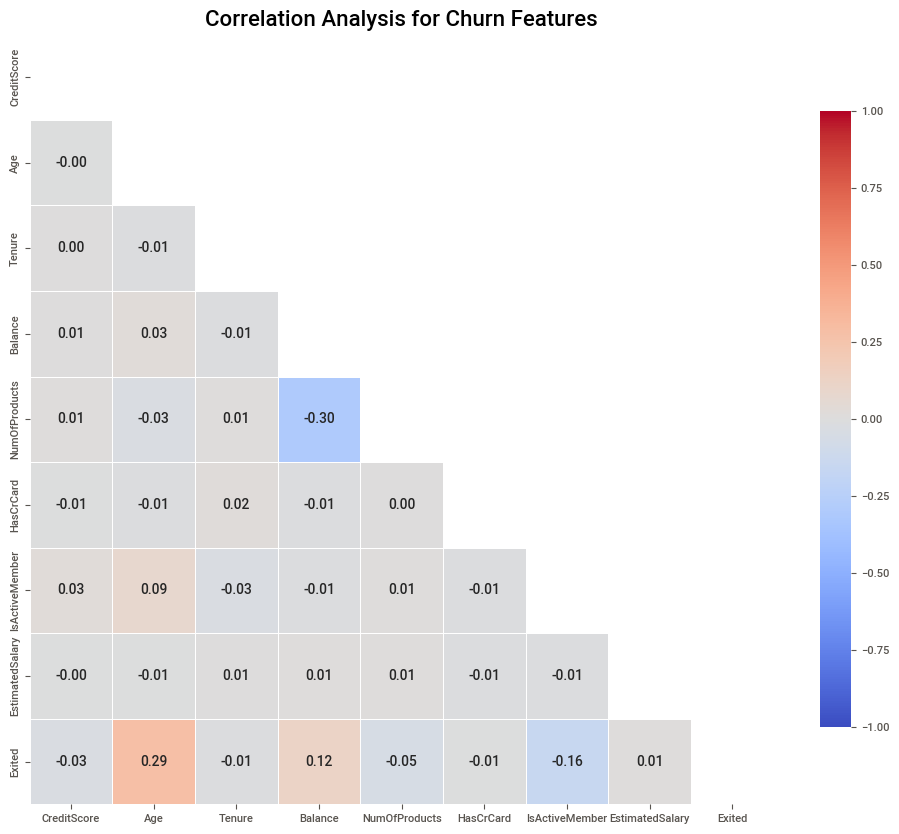

In [22]:
# We only calculate correlation for numeric columns
numeric_df = data.select_dtypes(include=[np.number])

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Create a mask for the upper triangle (optional, makes it cleaner)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Correlation Heatmap
# We use a diverging color map (coolwarm) to show positive and negative correlations.

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,          # Show the actual correlation values
    fmt=".2f",           # Two decimal places
    cmap='coolwarm',     # Red for positive, blue for negative
    vmin=-1, vmax=1,     # Ensure the scale is always -1 to 1
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Analysis for Churn Features', fontsize=16)

# Target Distribution

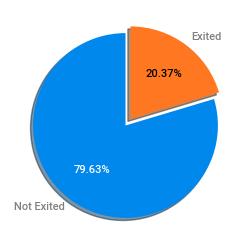

In [23]:
values = data['Exited'].value_counts()
labels = ['Not Exited', 'Exited']

fig, ax = plt.subplots(figsize = (4, 3), dpi = 100)
explode = (0, 0.09)

patches, texts, autotexts = ax.pie(values, labels = labels, autopct = '%1.2f%%', shadow = True,
                                   startangle = 90, explode = explode)

plt.setp(texts, color = 'grey')
plt.setp(autotexts, size = 8, color = 'white')
autotexts[1].set_color('black')
plt.show()

### 20% people have churned

# Visualize Categorical Features

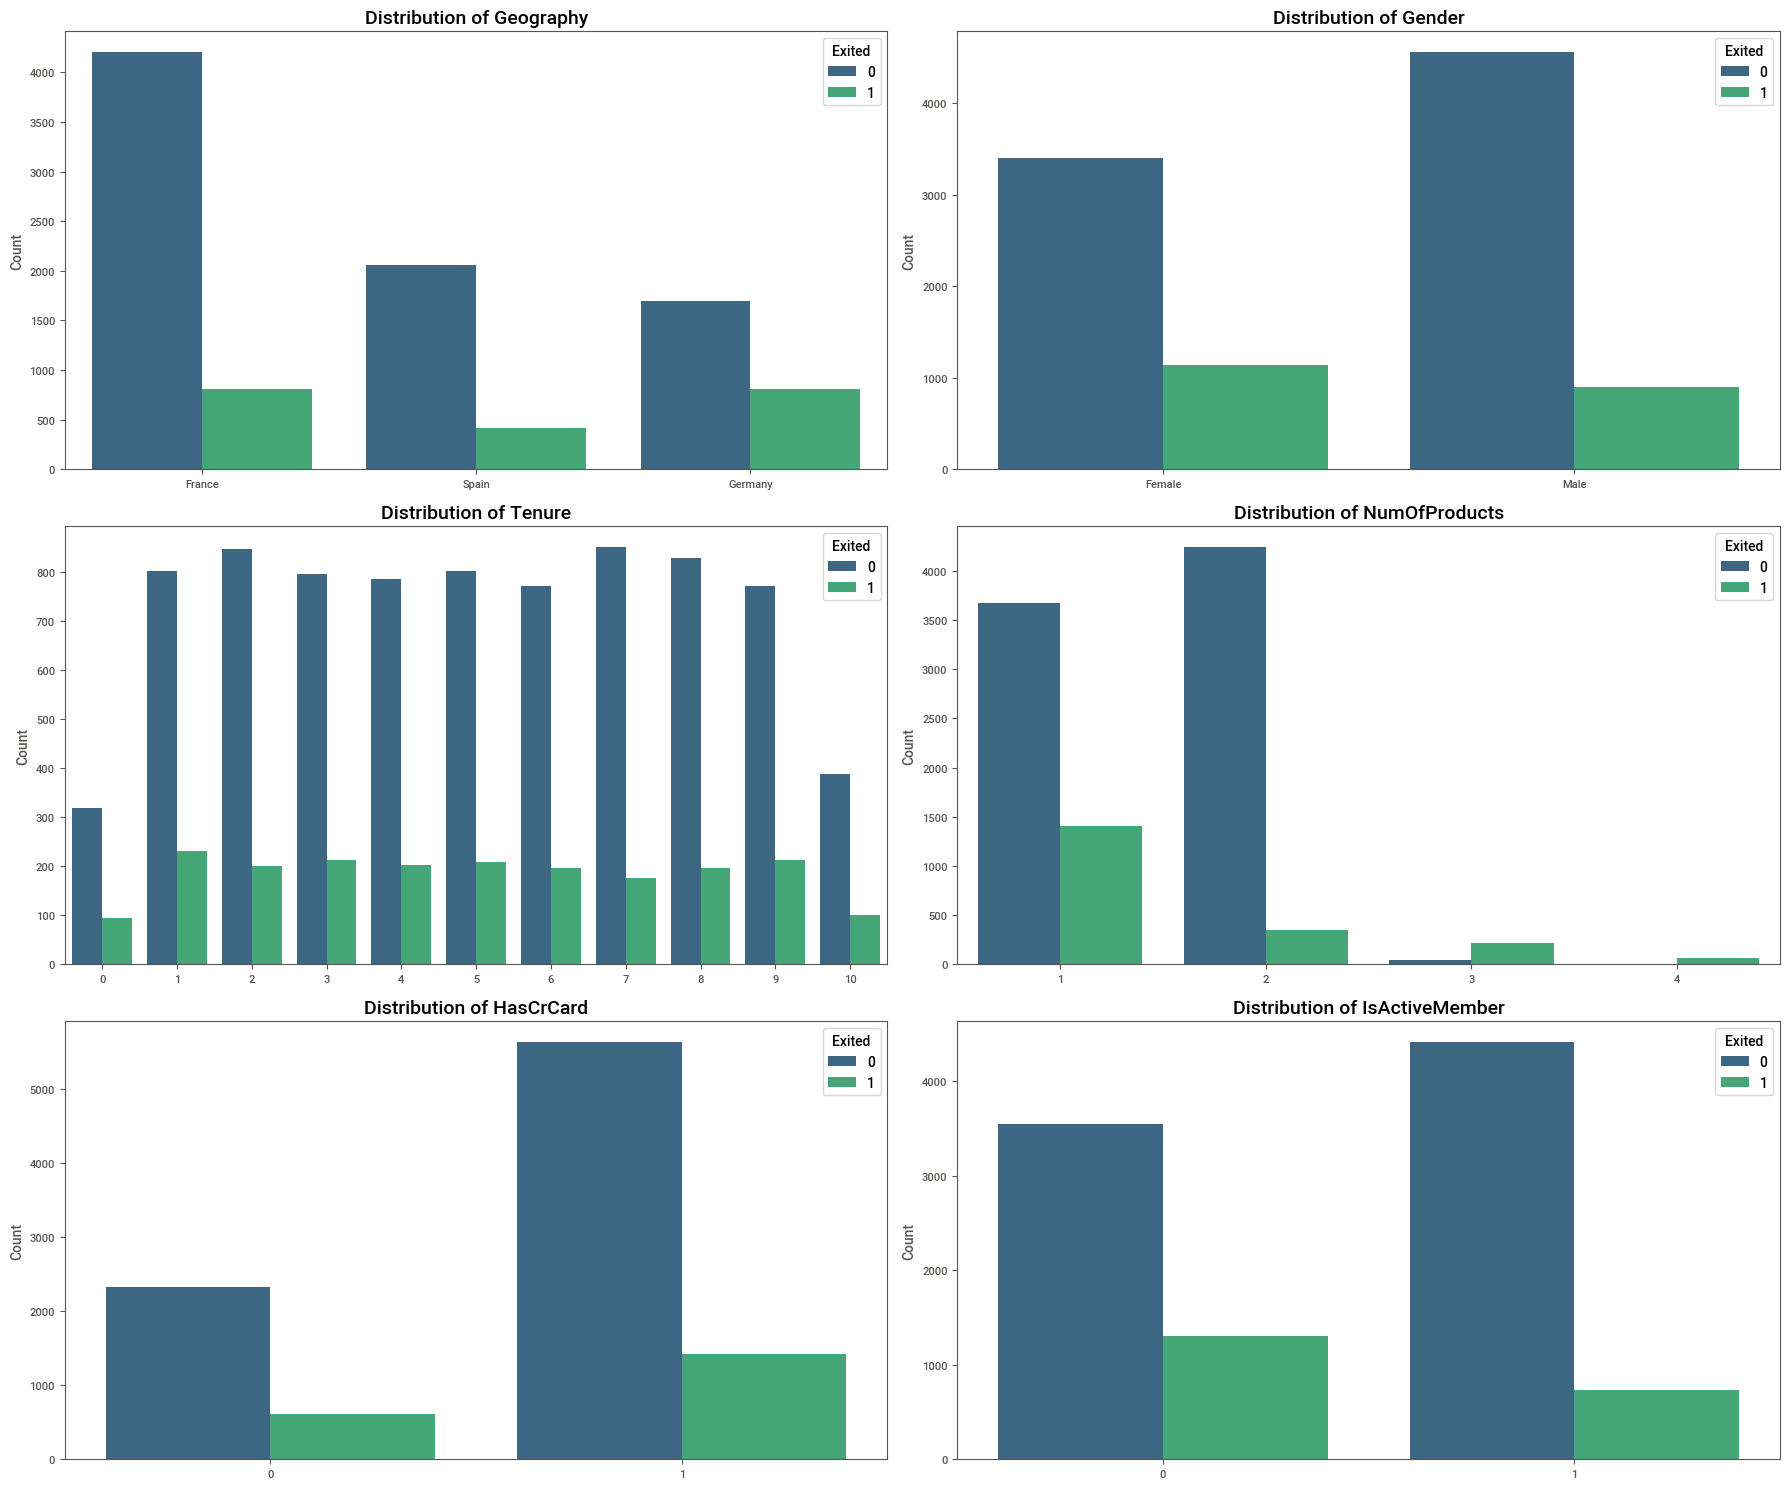

In [29]:
# Define the features you want to visualize
features = ['Geography', 'Gender', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']

# Create the grid dynamically
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 15))

# Flatten the axes array to iterate over it with a single index
axes = axes.flatten()

for i, col in enumerate(features):
    sns.countplot(x=col, hue='Exited', data=data, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Exited', loc='upper right')

# Clean up the layout
plt.tight_layout()
plt.show()

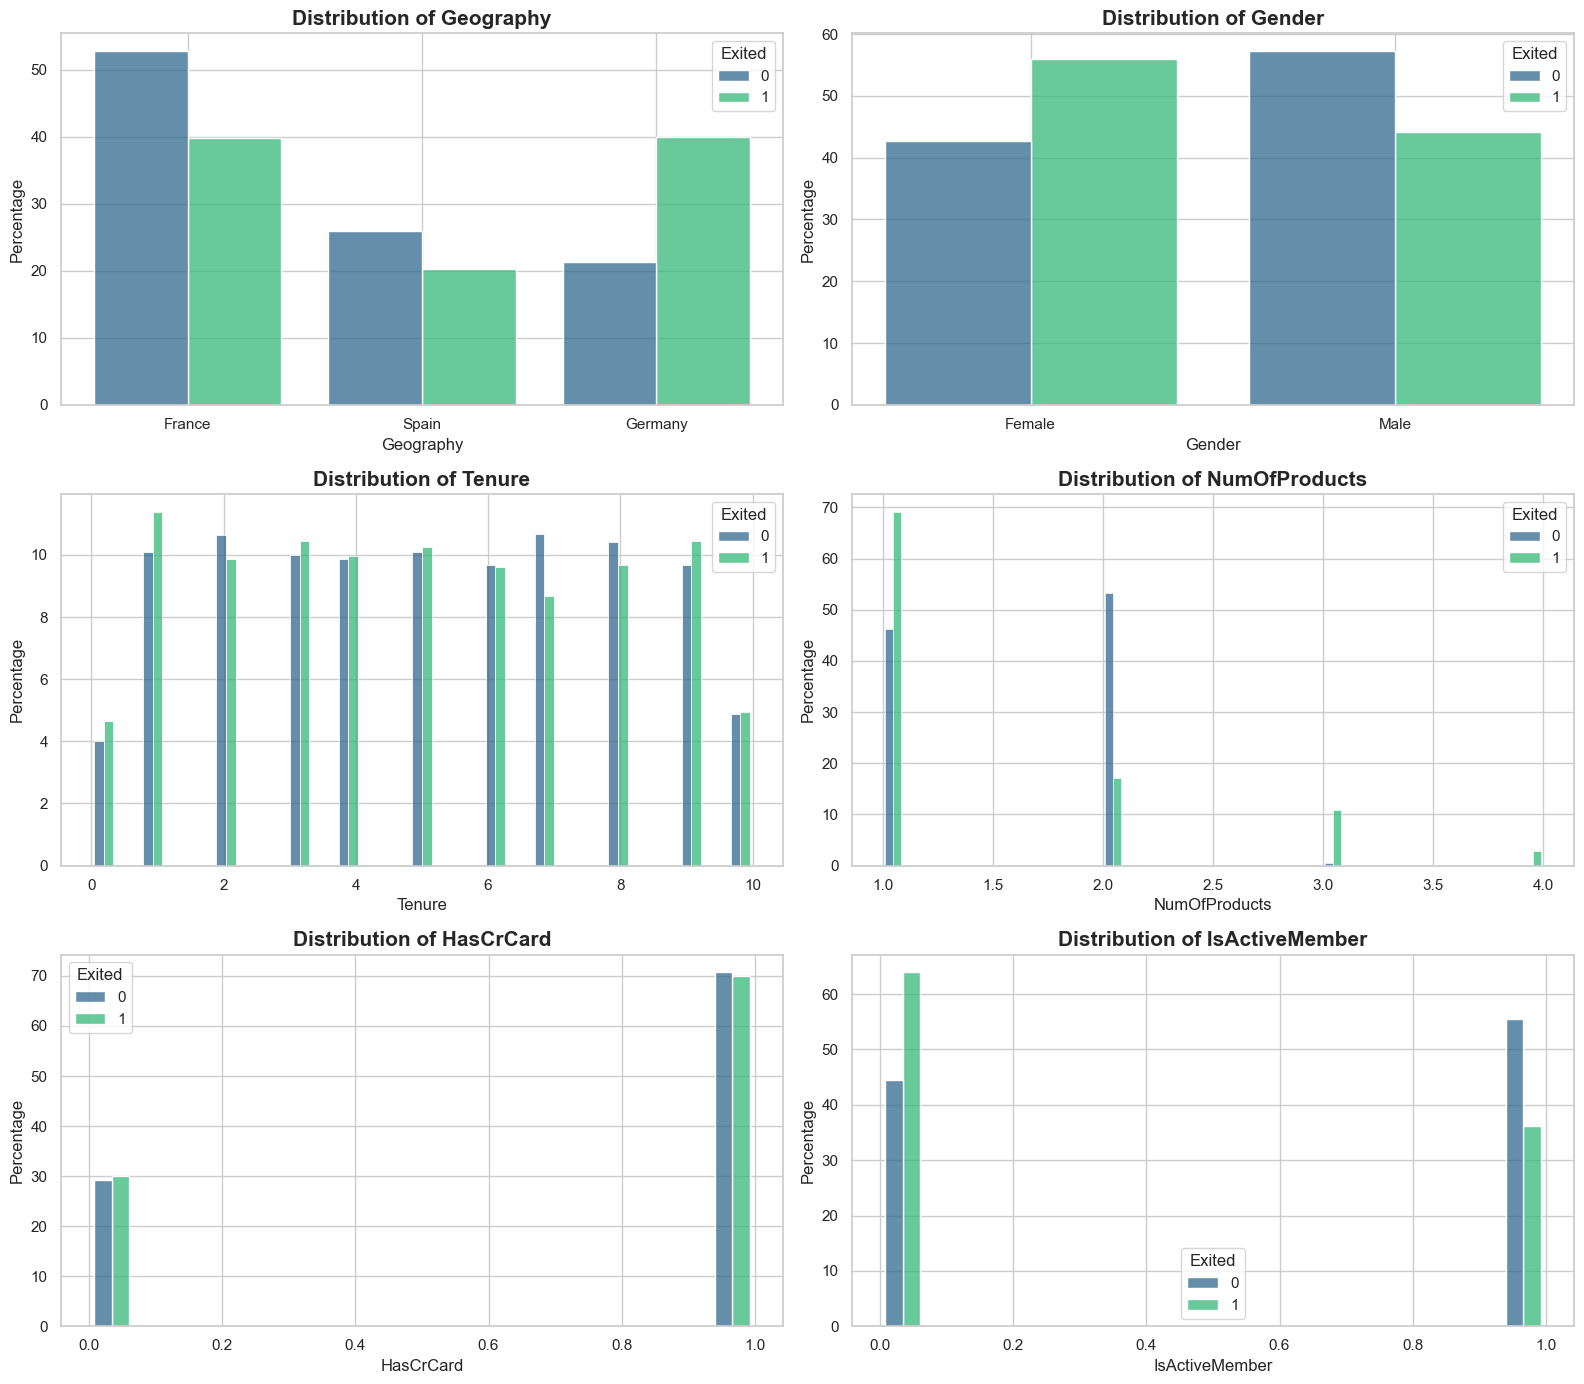

In [40]:
# Define the features you want to visualize
features = ['Geography', 'Gender', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']

# Set the style for better readability
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    # Use histplot with stat='percent' to achieve the "normalize=True" effect
    sns.histplot(
        data=data, 
        x=col, 
        hue='Exited', 
        multiple='dodge', 
        shrink=0.8, 
        ax=axes[i], 
        palette='viridis', 
        stat='percent', 
        common_norm=False
    )
    
    axes[i].set_title(f'Distribution of {col}', fontsize=15, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage')

plt.tight_layout()
plt.show()

- Geography wise France has the most customers but Germany has higher churn rate.
- Churn rate among females is higher than males.
- Tenure churn distribution seems consistent between years 1-9.
- Churn rate higher when num of products is higher than 2. However, countwise when customers have only 1 prodcut they tend to churn more. 
- Having a credit card doesn't have much effect on getting churned.
- Inactive members tend to churn more.

# Visualize Continuous Features

/var/folders/sb/4dgfp8rd1kj70rc2cmypbr9m0000gn/T/ipykernel_52815/4113801838.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y=col, data=data, ax=axes[i], palette='viridis')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/var/folders/sb/4dgfp8rd1kj70rc2cmypbr9m0000gn/T/ipykernel_52815/4113801838.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y=col, data=data, ax=axes[i], palette='viridis')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/var

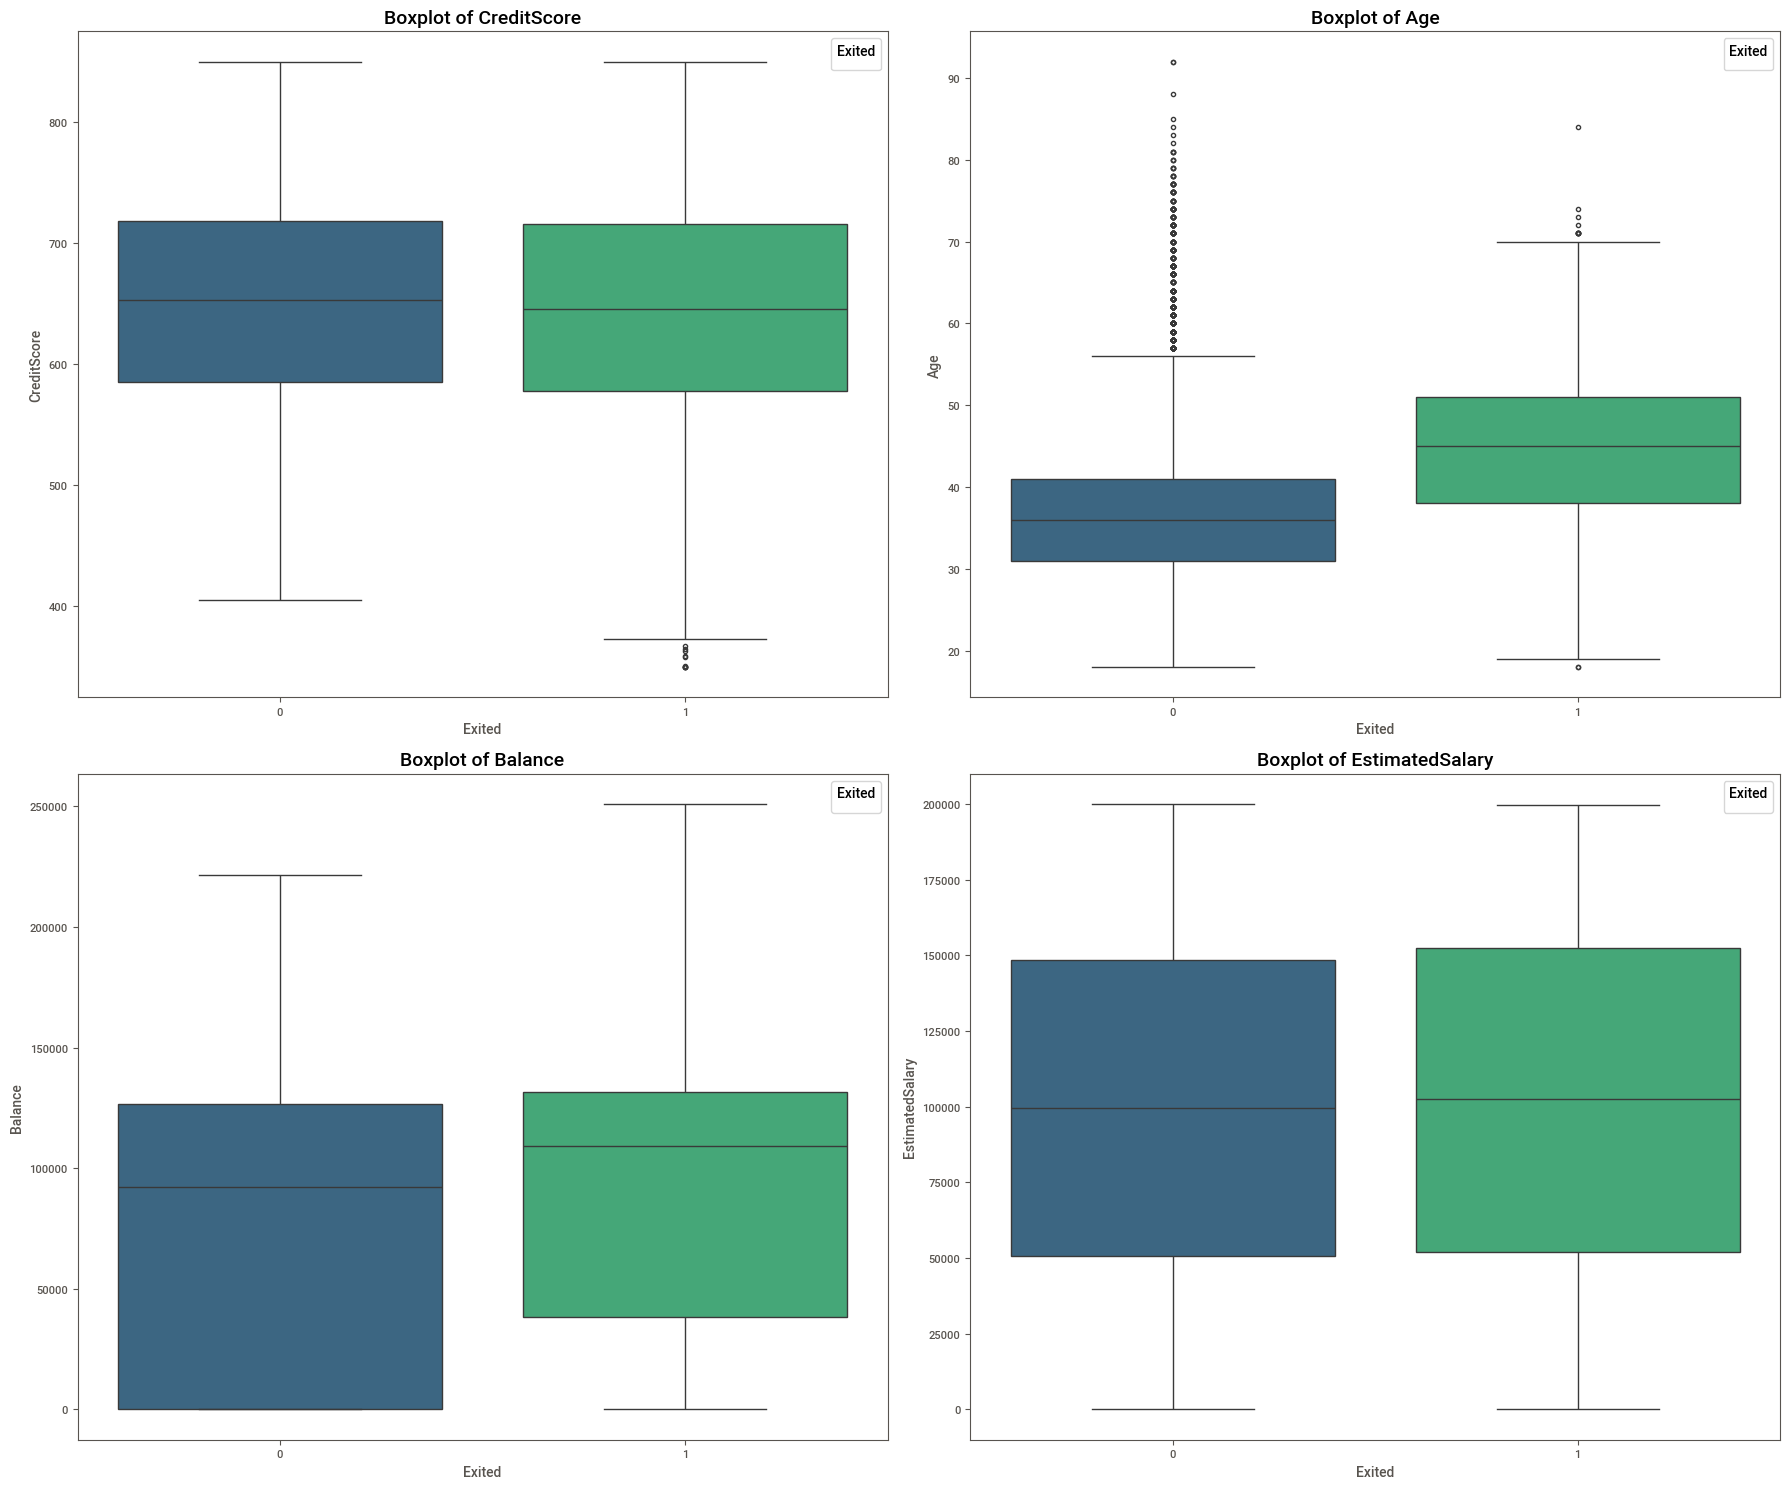

In [35]:
# Define the features you want to visualize
features = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

# Create the grid dynamically
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 15))

# Flatten the axes array to iterate over it with a single index
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x='Exited', y=col, data=data, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Boxplot of {col}', fontsize=14)
    axes[i].set_xlabel('Exited')
    axes[i].set_ylabel(col)
    axes[i].legend(title='Exited', loc='upper right')

# Clean up the layout
plt.tight_layout()
plt.show()

- Credit score doesn't have much effect on getting churned.
- Higher Age means higher chances of getting churned.
- Customers with higher balance tend to churn more.
- Est. Salary distribution doesn't differ between churned and non-churned customers. 